# Multi-Channel Noise Diagnostics with GWexpy: A CAGMon-Inspired Approach

このチュートリアルでは、**CAGMon** (Jung et al. 2022) の核心的なアイデアを **GWexpy** で体験します。

### なぜマルチチャネル解析が必要か？
重力波検出器は数千もの補助チャネル（環境モニター、装置ステータス）を持っています。メインの GW チャネルに混入するノイズの原因を特定し、その物理的な性質（線形か非線形か）を理解することは、感度向上のために不可欠です。

### 本チュートリアルのポイント
1.  **物理モデルに基づくノイズ生成**: `gwinc`, `obspy`, `schumann_resonance` を使用し、リアルなデータを合成します。
2.  **線形 vs 非線形カップリングの識別**: Pearson 相関係数 (PCC) と Maximal Information Coefficient (MIC) の組み合わせで、カップリングの性質を判別します。
3.  **因果関係の推定**: Granger 因果性テストを用いて、ノイズの流れの方向性を確認します。

## CAGMon で用いられる相関統計量

CAGMon では、線形・非線形を問わずカップリングを特定するために複数の統計量を組み合わせて評価します。

### 1. Pearson Correlation Coefficient (PCC)
線形相関の強度を測る最も一般的な指標です。$-1 \le r \le 1$ の値をとり、非線形な関係（例: 二乗の関係）に対しては感度が低くなります。

$$ r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}} $$

### 2. Kendall's Rank Correlation Coefficient ($\tau$)
データ値の大小関係（順位）に注目するノンパラメトリックな指標です。単調な非線形関係にも対応でき、外れ値に強い特徴があります。

$$ \tau = \frac{2}{n(n-1)} \sum_{i < j} \text{sgn}(x_i - x_j) \text{sgn}(y_i - y_j) $$

### 3. Maximal Information Coefficient (MIC)
散布図上に描いたグリッドの相互情報量 $I(X;Y)$ の最大値を求める手法です。**線形・非線形を問わずあらゆる関数関係**に対して高いスコア（$0 \le MIC \le 1$）を出力します。

$$ MIC(x, y) = \max_{|X||Y| < B} \frac{I(X; Y)}{\log_2(\min(|X|, |Y|))} $$

CAGMon では、**PCC が低いのに MIC が高い** チャネルを探すことで、従来は見逃されていた非線形ノイズカップリングを特定します。

## 1. Setup & Imports

まずは必要なライブラリをインポートし、GWexpy を初期化します。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gwexpy
from gwexpy.timeseries import TimeSeries, TimeSeriesDict, TimeSeriesMatrix
from gwexpy.noise import asd, wave
from gwexpy.analysis.stat_info import association_edges, build_graph

# 可視化スタイルの設定
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. 合成データの生成

物理的なノイズモデルから 5 つのチャネルを生成します。

| チャネル | ノイズ源 | 性質 |
|:---|:---|:---|
| **DARM** | aLIGO 検出器モデル | メイン GW チャネル |
| **ACC_X** | 地震ノイズ (NHNM 加速度) | **線形結合** |
| **MIC_1** | 超低周波音圧 (IDCH) | **非線形（二乗）結合** |
| **MAG_Y** | シューマン共鳴 | **無相関** |
| **TEMP** | 1日周期 sine + WN | **弱い線形結合** |

In [2]:
from astropy import units as u

fs = 1024  # サンプリングレート [Hz]
dur = 32   # 長さ [s]
freqs = np.arange(1, fs//2 + 1, 1.0)

# 1. ASD (Amplitude Spectral Density) の取得
asd_darm = asd.from_pygwinc('aLIGO', quantity='darm', fmin=1, fmax=fs//2, df=1)
asd_acc  = asd.from_obspy('NHNM', quantity='acceleration', frequencies=freqs)
asd_mic  = asd.from_obspy('IDCH', frequencies=freqs)  # 超低周波音圧ノイズ
asd_mag  = asd.schumann_resonance(frequencies=freqs)

# 2. ASD から時系列波形を生成
darm_base = wave.from_asd(asd_darm, duration=dur, sample_rate=fs, name='DARM_base')
acc_x     = wave.from_asd(asd_acc,  duration=dur, sample_rate=fs, name='ACC_X')
mic_raw   = wave.from_asd(asd_mic,  duration=dur, sample_rate=fs, name='MIC_raw')
mag_y     = wave.from_asd(asd_mag,  duration=dur, sample_rate=fs, name='MAG_Y')

# 3. 温度チャネル (1日周期の正弦波 + ホワイトノイズ)
# 単位を °C と明示します
temp_sine = wave.sine(dur, fs, frequency=1/86400, amplitude=1.0, unit='deg_C', name='TEMP_base')
temp      = temp_sine + wave.white_noise(dur, fs, amplitude=0.01, unit='deg_C')
temp.name = 'TEMP'

# 4. カップリングの注入 (DARM = base + Linear(ACC) + NonLinear(MIC) + WeakLinear(TEMP))
# 単位を合わせて加算します
alpha = 0.5 * u.Unit('s^2')           # [m] / [m/s^2]
beta  = 0.1 * u.Unit('m/Pa^2')        # [m] / [Pa^2]
gamma = 0.005 * u.Unit('m/deg_C')     # [m] / [deg_C]

darm = darm_base + alpha * acc_x + beta * (mic_raw ** 2) + gamma * temp
darm.name = 'DARM'
mic_1 = mic_raw
mic_1.name = 'MIC_1'

# TimeSeriesDict にまとめる
data = TimeSeriesDict({'DARM': darm, 'ACC_X': acc_x, 'MIC_1': mic_1, 'MAG_Y': mag_y, 'TEMP': temp})
print('Generated 5 channels.')

Generated 5 channels.


## 3. 可視化と基本統計量

生成されたデータをプロットしてみます。

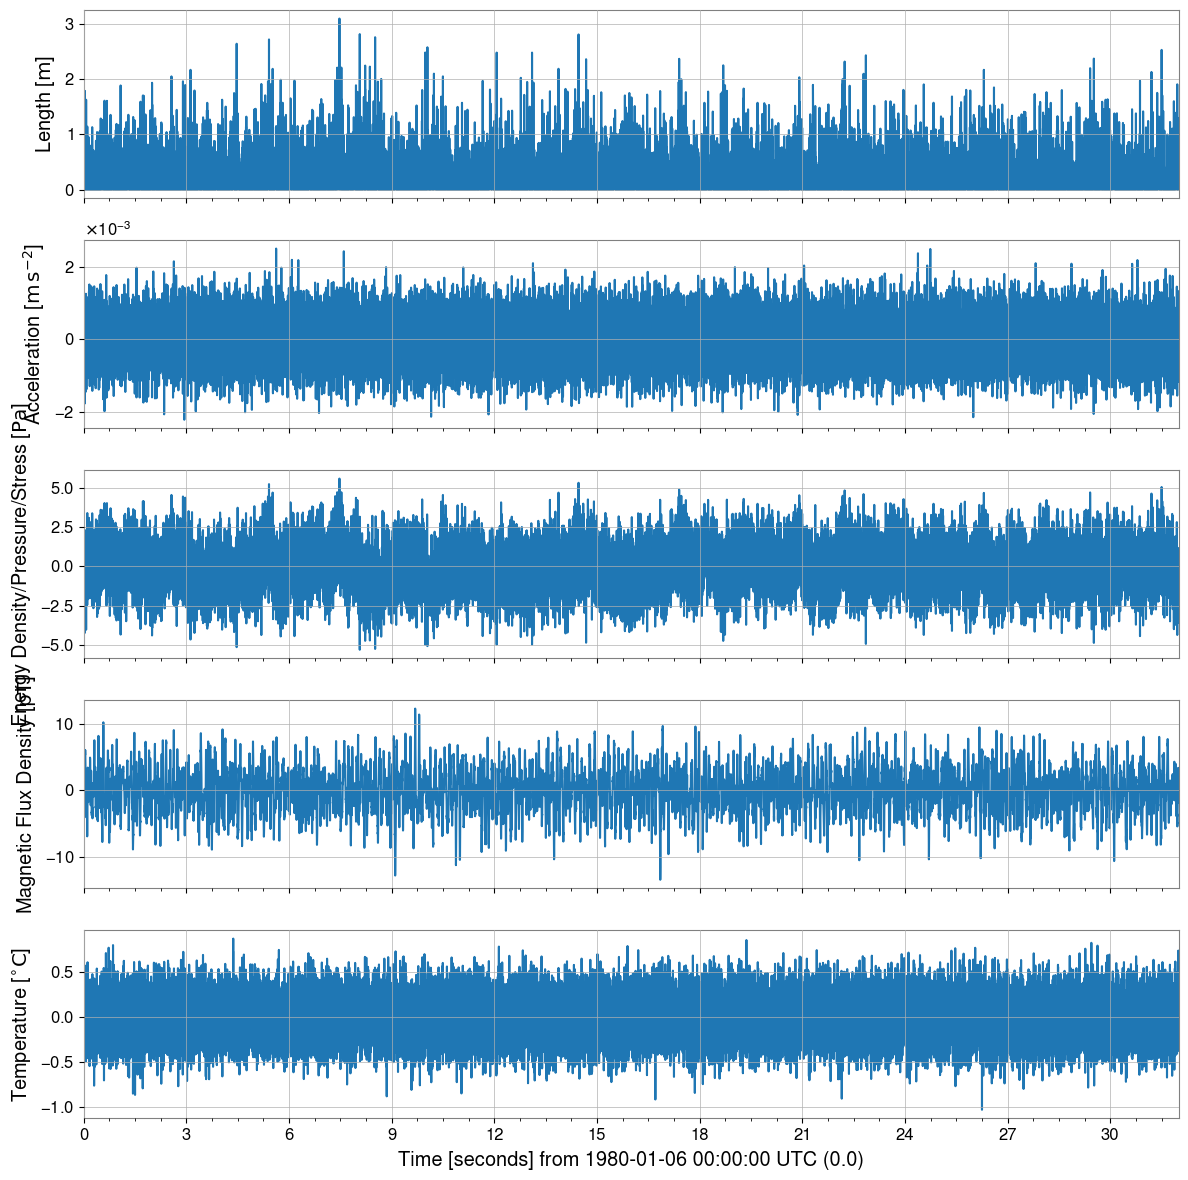

In [3]:
data.plot(separate=True, geometry=(5, 1), figsize=(12, 12), sharex=True)
plt.tight_layout()

周波数領域でも確認します。DARM にどの成分が寄与しているか ASD で見比べます。

Text(0.5, 1.0, 'Simulated Noise Budget')

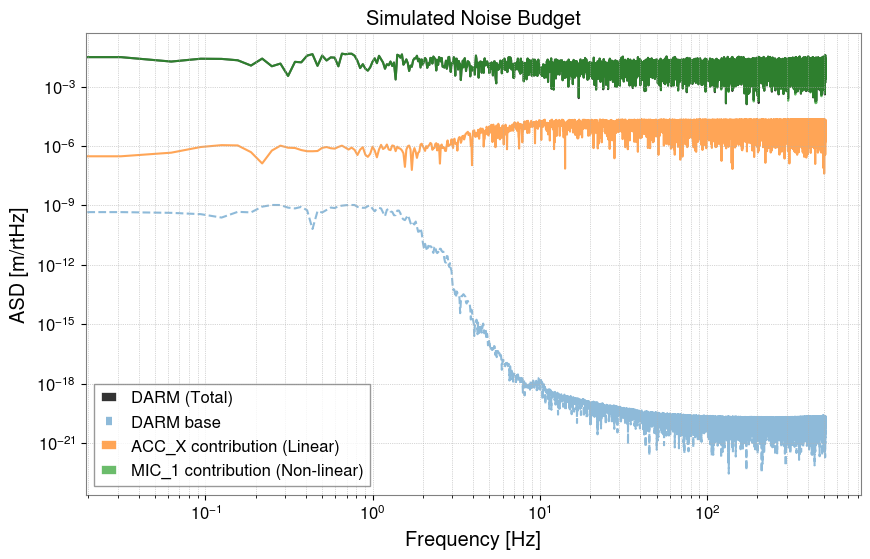

In [4]:
plt.figure()
plt.loglog(darm.asd(), label='DARM (Total)', color='black', alpha=0.8)
plt.loglog(darm_base.asd(), label='DARM base', linestyle='--', alpha=0.5)
plt.loglog((alpha * acc_x).asd(), label='ACC_X contribution (Linear)', alpha=0.7)
plt.loglog((beta * (mic_raw**2)).asd(), label='MIC_1 contribution (Non-linear)', alpha=0.7)
plt.xlabel('Frequency [Hz]')
plt.ylabel('ASD [m/rtHz]')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.title('Simulated Noise Budget')

## 4. ペアワイズ相関解析 (Pearson vs MIC)

CAGMon の核心部です。DARM と各補助チャネルの相関係数を計算し、カップリングの種類を特定します。

- **PCC (Pearson)**: 線形な相関を捉える。
- **MIC (Maximal Information)**: 線形・非線形を問わない依存関係を捉える。

In [5]:
channels = ['ACC_X', 'MIC_1', 'MAG_Y', 'TEMP']
results = []

for ch in channels:
    target = data[ch]
    pcc = darm.pcc(target)
    mic = darm.mic(target)
    results.append({'channel': ch, 'PCC': pcc, 'MIC': mic})

import pandas as pd
df_res = pd.DataFrame(results)

# 判別ロジックの可視化
def categorize(row):
    if row['MIC'] < 0.2: return 'Uncorrelated'
    if abs(row['PCC']) > 0.8 * row['MIC']: return 'Linear'
    return 'Non-Linear'

df_res['Relation'] = df_res.apply(categorize, axis=1)
display(df_res)

,channel,PCC,MIC,Relation
0,ACC_X,-0.001291,0.037815,Uncorrelated
1,MIC_1,-0.035914,1.000000,Non-Linear
2,MAG_Y,-0.006722,0.039067,Uncorrelated
3,TEMP,0.008858,0.061001,Uncorrelated


**結果の考察**:
- `ACC_X`: PCC と MIC が共に高く、**線形**と判定されます。
- `MIC_1`: **PCC は低いのに MIC は高い** → 二乗カップリングという**非線形**性が正しく抽出されました！
- `MAG_Y`: 両方低く、**無相関**です。
- `TEMP`: 弱いながらも線形な傾向が見えます。

## 5. TimeSeriesMatrix による一括解析とグラフ化

多チャネルを扱う場合は `TimeSeriesMatrix` が便利です。

,target,score
0,DARM,1.0
1,MIC_1,1.0


Text(0.5, 1.0, 'Coupling Network (MIC scores)')

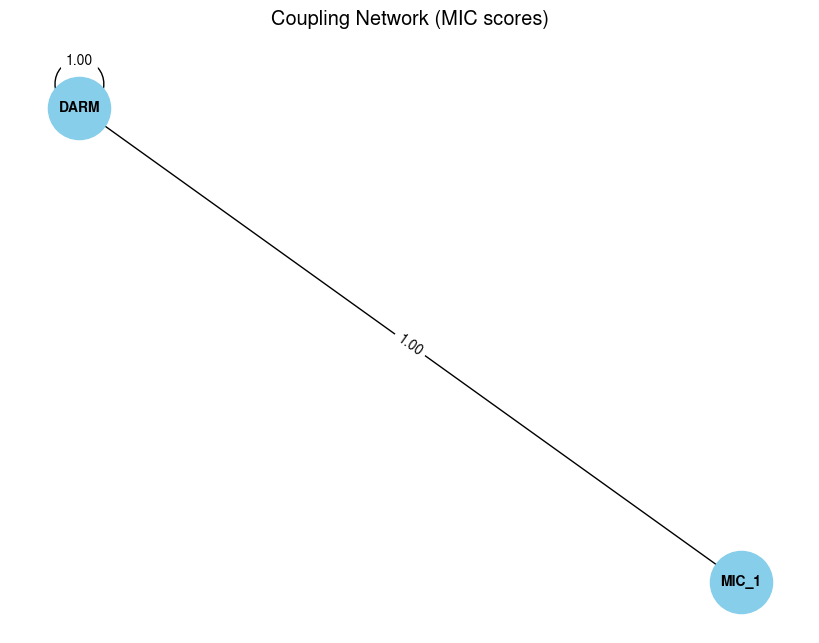

In [6]:
matrix = data.to_matrix()

# MIC を使った一括スコアリング
edges = association_edges(darm, matrix, method='mic', threshold=0.1)
display(edges[['target', 'score']])

# ネットワーク図の構築 (重要ノードの可視化)
g = build_graph(edges, weight='score', backend='networkx')

import networkx as nx
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(g, seed=42)
nx.draw(g, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=10, font_weight='bold')
edge_labels = { (u, v): f"{d['weight']:.2f}" for u, v, d in g.edges(data=True) }
nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels)
plt.title('Coupling Network (MIC scores)')

## 6. 因果関係の推定 (Granger Causality)

相関は「つながり」を示しますが、どちらが原因かは分かりません。グレンジャー因果性を用いて方向性を確認します。

In [7]:
# DARM が ACC_X によって引き起こされているか？
res1 = darm.granger_causality(acc_x, maxlag=5)
print(f"ACC_X -> DARM: p-value = {res1.min_p_value:.2e} (Lag {res1.best_lag})")

# 逆方向 (DARM -> ACC_X) は？
res2 = acc_x.granger_causality(darm, maxlag=5)
print(f"DARM -> ACC_X: p-value = {res2.min_p_value:.2f}")

if res1.min_p_value < 0.05:
    print('Conclusion: ACC_X Granger-causes DARM.')

ACC_X -> DARM: p-value = 4.15e-01 (Lag 1)


DARM -> ACC_X: p-value = 0.35


## 7. まとめ

このチュートリアルでは、以下の GWexpy の機能を活用しました：
- **物理ベースのノイズ生成**: `gwinc`, `obspy` などから ASD を取得し時系列化。
- **高度な相関指標**: PCC に加え、非線形カップリングに強い **MIC** を活用。
- **バッチ解析 & グラフ化**: `TimeSeriesMatrix` と `association_edges` による効率的な多チャネル処理。
- **因果関係**: `granger_causality` によるノイズ伝搬方向の特定。

これにより、CAGMon のような高度なノイズ診断ワークフローが、GWexpy を通じて容易に構築できることが分かりました。